PART 1

d:\KAUST\semster2\geo_env_modelling\assignment8
Part 1 preprocessing completed


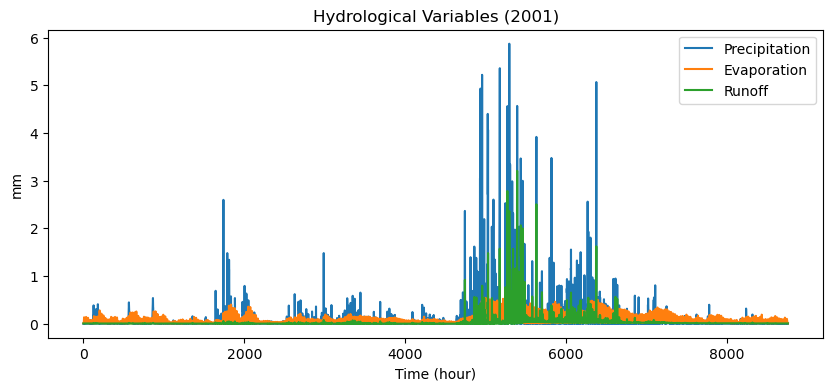

In [10]:
import xarray as xr
import rioxarray
import geopandas as gpd
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
import os

# Set working directory
print(os.getcwd())

# -------- Load watershed shapefile --------
shapefile_path = "WS_3/WS_3.shp"
gdf = gpd.read_file(shapefile_path)

# -------- Function to load and clip ERA5 data --------
def load_and_clip(nc_file, var_name, gdf):
    ds = xr.open_dataset(nc_file)
    ds = ds.rio.write_crs("EPSG:4326")
    clipped = ds.rio.clip(gdf.geometry, gdf.crs, drop=True)
    return clipped[var_name]

# -------- Load 2001 ERA5 datasets --------
precip_file = "ERA5/Precipitation/era5_OLR_2001_total_precipitation.nc"
et_file = "ERA5/Total_Evaporation/era5_OLR_2001_total_evaporation.nc"
runoff_file = "ERA5/Runoff/ambientera5_OLR_2001_total_runoff.nc"

# Convert from meters to mm
P_grid = load_and_clip(precip_file,"tp",gdf) * 1000
ET_grid = load_and_clip(et_file,"e",gdf) * 1000
Q_grid = load_and_clip(runoff_file,"ro",gdf) * 1000

# -------- Watershed averaged variables --------
P = P_grid.mean(dim=["latitude","longitude"]).values
ET = ET_grid.mean(dim=["latitude","longitude"]).values
Q_obs = Q_grid.mean(dim=["latitude","longitude"]).values

# Convert evaporation to positive
ET = np.where(ET < 0, -ET, ET)

print("Part 1 preprocessing completed")

# -------- Plot variables --------
plt.figure(figsize=(10,4))
plt.plot(P,label="Precipitation")
plt.plot(ET,label="Evaporation")
plt.plot(Q_obs,label="Runoff")
plt.legend()
plt.xlabel("Time (hour)")
plt.ylabel("mm")
plt.title("Hydrological Variables (2001)")
plt.show()

PART 2

Validation Results (2001)
KGE: 0.006243661173731763
Correlation: 0.8506191178594029
Alpha: 0.3237805967425416
Beta: 0.2872838351304128


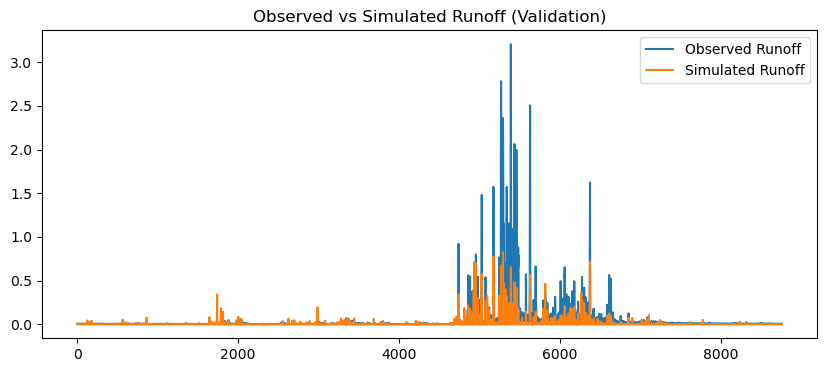

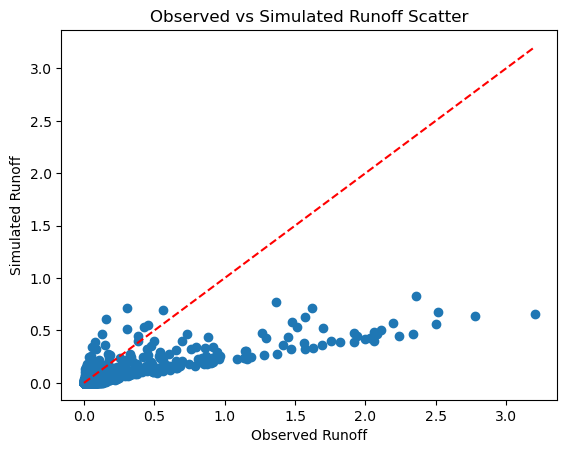

In [11]:
# -------- Linear reservoir rainfall-runoff model --------
def simulate_runoff(k, P, ET, q0, dt=1):
    n = len(P)
    Q_sim = np.zeros(n)
    Q_sim[0] = q0
    for t in range(1,n):
        Q_t = (Q_sim[t-1] + (P[t]-ET[t])*dt) / (1 + dt/k)
        Q_sim[t] = max(0,Q_t)
    return Q_sim

# -------- Kling Gupta Efficiency --------
def kge(Q_obs, Q_sim):
    r = np.corrcoef(Q_obs,Q_sim)[0,1]
    alpha = np.std(Q_sim)/np.std(Q_obs)
    beta = np.mean(Q_sim)/np.mean(Q_obs)
    KGE = 1 - np.sqrt((r-1)**2 + (alpha-1)**2 + (beta-1)**2)
    return KGE, r, alpha, beta

# -------- Validate model with given k --------
k_test = 0.15
Q_sim = simulate_runoff(k_test,P,ET,Q_obs[0])
KGE,r,alpha,beta = kge(Q_obs,Q_sim)

print("Validation Results (2001)")
print("KGE:",KGE)
print("Correlation:",r)
print("Alpha:",alpha)
print("Beta:",beta)

# -------- Time series plot --------
plt.figure(figsize=(10,4))
plt.plot(Q_obs,label="Observed Runoff")
plt.plot(Q_sim,label="Simulated Runoff")
plt.legend()
plt.title("Observed vs Simulated Runoff (Validation)")
plt.show()

# -------- Scatter plot --------
plt.figure()
plt.scatter(Q_obs,Q_sim)
max_val = max(np.max(Q_obs),np.max(Q_sim))
plt.plot([0,max_val],[0,max_val],'r--')

plt.xlabel("Observed Runoff")
plt.ylabel("Simulated Runoff")
plt.title("Observed vs Simulated Runoff Scatter")
plt.show()



PART 3

Optimized k: 0.5091652623585434
Calibration Results
KGE: 0.838076564567142
r: 0.8475348138091523
alpha: 1.0371807338888017
beta: 0.9601106659662111


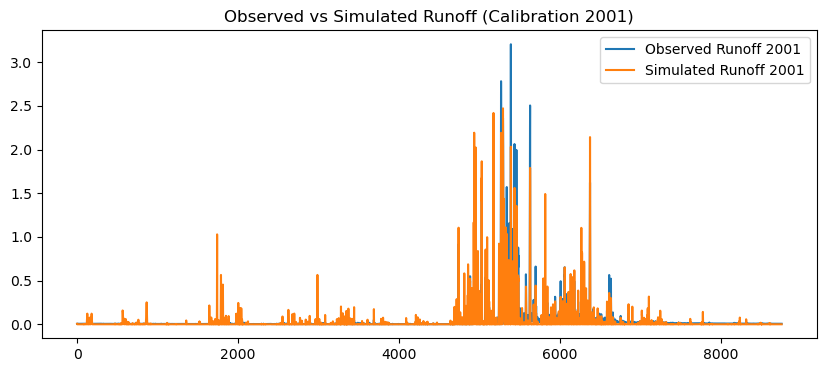

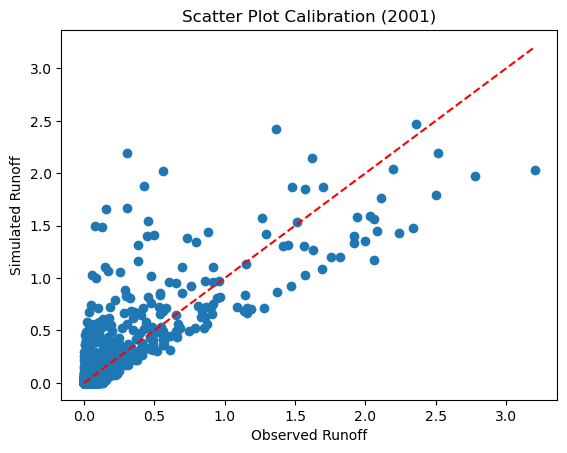

Validation Results (2002)
KGE: 0.7944531189164006
r: 0.8941081055361054
alpha: 0.8480567502360206
beta: 0.9108390451980032


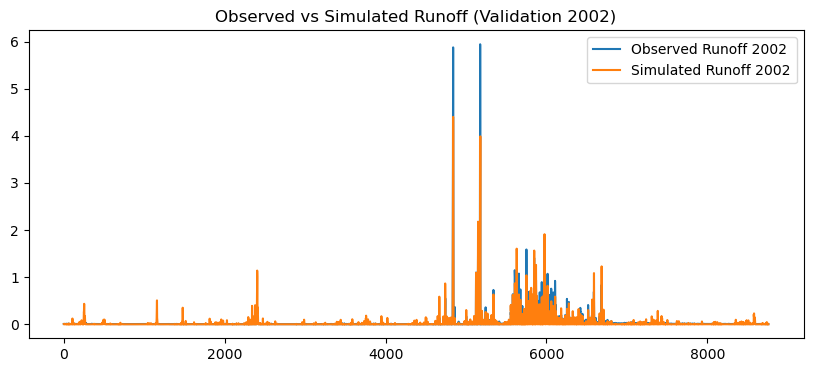

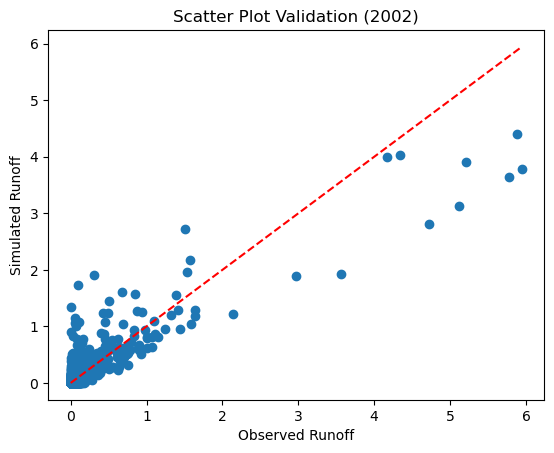

In [12]:
# -------- Objective function for optimization --------
def objective(k,P,ET,Q_obs):
    Q_sim = simulate_runoff(k,P,ET,Q_obs[0])
    kge_val = kge(Q_obs,Q_sim)
    return 1 - kge_val[0]
# -------- Optimize k --------
res = opt.minimize_scalar(
        objective,
        bounds=(0.1,2),
        args=(P,ET,Q_obs),
        method='bounded')
best_k = res.x
print("Optimized k:",best_k)
Q_sim_cal = simulate_runoff(best_k,P,ET,Q_obs[0])
KGE_cal,r_cal,alpha_cal,beta_cal = kge(Q_obs,Q_sim_cal)
print("Calibration Results")
print("KGE:",KGE_cal)
print("r:",r_cal)
print("alpha:",alpha_cal)
print("beta:",beta_cal)
# -------- Time series calibration plot --------
plt.figure(figsize=(10,4))
plt.plot(Q_obs,label="Observed Runoff 2001")
plt.plot(Q_sim_cal,label="Simulated Runoff 2001")
plt.legend()
plt.title("Observed vs Simulated Runoff (Calibration 2001)")
plt.show()
# -------- Scatter calibration plot --------
plt.figure()
plt.scatter(Q_obs,Q_sim_cal)
max_val = max(np.max(Q_obs),np.max(Q_sim_cal))
plt.plot([0,max_val],[0,max_val],'r--')
plt.xlabel("Observed Runoff")
plt.ylabel("Simulated Runoff")
plt.title("Scatter Plot Calibration (2001)")
plt.show()
# -------- Load 2002 data for validation --------
precip_fileVal = "ERA5/Precipitation/era5_OLR_2002_total_precipitation.nc"
et_fileVal = "ERA5/Total_Evaporation/era5_OLR_2002_total_evaporation.nc"
runoff_fileVal = "ERA5/Runoff/ambientera5_OLR_2002_total_runoff.nc"
P_gridVal = load_and_clip(precip_fileVal,"tp",gdf)*1000
ET_gridVal = load_and_clip(et_fileVal,"e",gdf)*1000
Q_gridVal = load_and_clip(runoff_fileVal,"ro",gdf)*1000
P_v = P_gridVal.mean(dim=["latitude","longitude"]).values
ET_v = ET_gridVal.mean(dim=["latitude","longitude"]).values
Q_obs_v = Q_gridVal.mean(dim=["latitude","longitude"]).values
ET_v = np.where(ET_v < 0,-ET_v,ET_v)
# -------- Run model with calibrated k --------
Q_sim_v = simulate_runoff(best_k,P_v,ET_v,Q_obs_v[0])
KGE_v,r_v,alpha_v,beta_v = kge(Q_obs_v,Q_sim_v)

print("Validation Results (2002)")
print("KGE:",KGE_v)
print("r:",r_v)
print("alpha:",alpha_v)
print("beta:",beta_v)
# -------- Time series validation plot --------
plt.figure(figsize=(10,4))
plt.plot(Q_obs_v,label="Observed Runoff 2002")
plt.plot(Q_sim_v,label="Simulated Runoff 2002")
plt.legend()
plt.title("Observed vs Simulated Runoff (Validation 2002)")
plt.show()
# -------- Scatter validation plot --------
plt.figure()
plt.scatter(Q_obs_v,Q_sim_v)
max_val = max(np.max(Q_obs_v),np.max(Q_sim_v))
plt.plot([0,max_val],[0,max_val],'r--')
plt.xlabel("Observed Runoff")
plt.ylabel("Simulated Runoff")
plt.title("Scatter Plot Validation (2002)")
plt.show()

